In [1]:
from transformers import pipeline

# Load the model directly using pipeline
nlp = pipeline("text-classification", model="yiyanghkust/finbert-esg", top_k=None)

# Input text
text = "The company has committed to reducing its carbon footprint by 50% by 2030."
results = nlp(text)

print(results)

Device set to use cpu


[[{'label': 'Environmental', 'score': 0.9921269416809082}, {'label': 'None', 'score': 0.004601624328643084}, {'label': 'Social', 'score': 0.001839135424233973}, {'label': 'Governance', 'score': 0.0014322715578600764}]]


In [7]:
import json
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm


def _prediction_to_prob_dict(prediction) -> dict:
    """Convert pipeline output for one sentence into {label: score} dict."""
    if isinstance(prediction, list):
        return {
            str(item.get("label")): float(item.get("score", 0.0))
            for item in prediction
            if isinstance(item, dict)
        }

    if isinstance(prediction, dict):
        return {str(prediction.get("label")): float(prediction.get("score", 0.0))}

    return {}


def write_ticker_esg_sentence_csvs(
    ticker_folders_root,
    master_sentences_csv,
    classifier=None,
    output_suffix="_esg_sentence_probs.csv",
    batch_size=64,
    show_progress=True,
):
    """
    Read a master sentence CSV, score each sentence with FinBERT ESG, and write one CSV per ticker folder.

    Parameters
    ----------
    ticker_folders_root : str | Path
        Path to directory containing per-ticker folders (e.g., sec_filings/ADP, sec_filings/BR, ...).
    master_sentences_csv : str | Path
        Path to master sentence CSV (must include at least: ticker, sentence_text).
    classifier : transformers pipeline, optional
        ESG text-classification pipeline. If None, uses global `nlp` from Cell 1.
    output_suffix : str
        Output filename suffix written in each ticker folder.
    batch_size : int
        Number of sentences to score per batch.
    show_progress : bool
        Whether to show tqdm progress bars with ETA.
    """
    ticker_folders_root = Path(ticker_folders_root)
    master_sentences_csv = Path(master_sentences_csv)

    if classifier is None:
        classifier = globals().get("nlp")

    if classifier is None:
        raise RuntimeError("No classifier found. Run Cell 1 first so `nlp` is available.")

    if not ticker_folders_root.exists() or not ticker_folders_root.is_dir():
        raise FileNotFoundError(f"Ticker folders root not found or not a directory: {ticker_folders_root}")

    if not master_sentences_csv.exists():
        raise FileNotFoundError(f"Master sentence CSV not found: {master_sentences_csv}")

    df = pd.read_csv(master_sentences_csv)

    required_columns = {"ticker", "sentence_text"}
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f"Master CSV missing required columns: {sorted(missing_columns)}")

    written = 0
    skipped_missing_folder = []

    ticker_groups = list(df.groupby("ticker", sort=False))
    ticker_iterator = tqdm(
        ticker_groups,
        desc="Tickers",
        unit="ticker",
        dynamic_ncols=True,
        leave=True,
        disable=not show_progress,
    )

    for ticker, ticker_df in ticker_iterator:
        ticker_folder = ticker_folders_root / str(ticker)
        if not ticker_folder.exists() or not ticker_folder.is_dir():
            skipped_missing_folder.append(str(ticker))
            continue

        ticker_df = ticker_df.copy()
        texts = ticker_df["sentence_text"].fillna("").astype(str).tolist()

        all_predictions = []
        batch_starts = range(0, len(texts), batch_size)
        total_batches = (len(texts) + batch_size - 1) // batch_size

        batch_iterator = tqdm(
            batch_starts,
            total=total_batches,
            desc=f"{ticker} batches",
            unit="batch",
            dynamic_ncols=True,
            leave=False,
            disable=not show_progress,
        )

        for start in batch_iterator:
            batch_texts = texts[start : start + batch_size]
            batch_predictions = classifier(batch_texts, truncation=True, max_length=512)
            all_predictions.extend(batch_predictions)

        if len(all_predictions) != len(ticker_df):
            raise RuntimeError(
                f"Prediction count mismatch for {ticker}: {len(all_predictions)} vs {len(ticker_df)}"
            )

        prob_dicts = [_prediction_to_prob_dict(pred) for pred in all_predictions]

        output_df = ticker_df.copy()
        output_df["esg_probabilities"] = [json.dumps(d, ensure_ascii=False) for d in prob_dicts]

        output_path = ticker_folder / f"{ticker}{output_suffix}"
        output_df.to_csv(output_path, index=False, encoding="utf-8")
        written += 1

    print(f"Master rows processed: {len(df)}")
    print(f"Ticker CSVs written: {written}")

    if skipped_missing_folder:
        print(
            f"Skipped tickers (no folder found under {ticker_folders_root}): {sorted(set(skipped_missing_folder))}"
        )


# --- Run configuration ---
ticker_folders_root = Path("sec_filings")
master_sentences_csv_path = Path("outputs/master_risk_sentences.csv")

write_ticker_esg_sentence_csvs(
    ticker_folders_root=ticker_folders_root,
    master_sentences_csv=master_sentences_csv_path,
    classifier=nlp,
    output_suffix="_esg_sentence_probs.csv",
    batch_size=64,
    show_progress=True,
)


Tickers:   0%|          | 0/28 [00:00<?, ?ticker/s]

ADP batches:   0%|          | 0/21 [00:00<?, ?batch/s]

BR batches:   0%|          | 0/32 [00:00<?, ?batch/s]

CHRW batches:   0%|          | 0/27 [00:00<?, ?batch/s]

CMI batches:   0%|          | 0/36 [00:00<?, ?batch/s]

...

UBER batches:   0%|          | 0/121 [00:00<?, ?batch/s]

URI batches:   0%|          | 0/40 [00:00<?, ?batch/s]

WAB batches:   0%|          | 0/33 [00:00<?, ?batch/s]

WM batches:   0%|          | 0/57 [00:00<?, ?batch/s]

Master rows processed: 76217
Ticker CSVs written: 28


In [1]:
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm
import tiktoken

def append_token_counts_to_esg_csvs(
    ticker_folders_root,
    sentence_col="sentence_text",
    input_suffix="_esg_sentence_probs.csv",
    token_col="token_count",
    encoding_name="cl100k_base",
    overwrite=True,
    output_suffix="_esg_sentence_probs_with_tokens.csv",
    show_progress=True,
):
    """
    For each ticker folder under `ticker_folders_root`, find ESG sentence probability CSVs,
    compute token counts from the sentence column using tiktoken, and append as a new column.
    """
    ticker_folders_root = Path(ticker_folders_root)

    if not ticker_folders_root.exists() or not ticker_folders_root.is_dir():
        raise FileNotFoundError(f"Ticker folders root not found or not a directory: {ticker_folders_root}")

    encoder = tiktoken.get_encoding(encoding_name)

    ticker_dirs = sorted([p for p in ticker_folders_root.iterdir() if p.is_dir()])

    processed = 0
    skipped_no_csv = []
    skipped_missing_sentence_col = []

    ticker_iter = tqdm(
        ticker_dirs,
        desc="Tickers",
        unit="ticker",
        dynamic_ncols=True,
        disable=not show_progress,
    )

    for ticker_dir in ticker_iter:
        ticker = ticker_dir.name
        input_path = ticker_dir / f"{ticker}{input_suffix}"

        if not input_path.exists():
            skipped_no_csv.append(ticker)
            continue

        df = pd.read_csv(input_path)
        if sentence_col not in df.columns:
            skipped_missing_sentence_col.append(ticker)
            continue

        sentences = df[sentence_col].fillna("").astype(str).tolist()
        df[token_col] = [len(encoder.encode(text)) for text in sentences]

        if overwrite:
            output_path = input_path
        else:
            output_path = ticker_dir / f"{ticker}{output_suffix}"

        df.to_csv(output_path, index=False, encoding="utf-8")
        processed += 1

    print(f"Processed ticker CSVs: {processed}")
    print(f"Skipped (no ESG CSV found): {len(skipped_no_csv)}")
    print(f"Skipped (missing '{sentence_col}' column): {len(skipped_missing_sentence_col)}")

    if skipped_missing_sentence_col:
        print(f"Tickers missing '{sentence_col}': {sorted(skipped_missing_sentence_col)}")


# --- Run configuration ---
ticker_folders_root = Path("sec_filings")

append_token_counts_to_esg_csvs(
    ticker_folders_root=ticker_folders_root,
    sentence_col="sentence_text",
    input_suffix="_esg_sentence_probs.csv",
    token_col="token_count",
    encoding_name="cl100k_base",
    overwrite=True,
    show_progress=True,
)


Tickers:   0%|          | 0/79 [00:00<?, ?ticker/s]

Processed ticker CSVs: 28
Skipped (no ESG CSV found): 51
Skipped (missing 'sentence_text' column): 0


In [2]:
import json
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm


def _parse_prob_dict(value):
    """Parse esg_probabilities cell into a dict."""
    if isinstance(value, dict):
        return value

    if pd.isna(value):
        return {}

    text = str(value).strip()
    if not text:
        return {}

    try:
        parsed = json.loads(text)
        if isinstance(parsed, dict):
            return parsed
    except Exception:
        pass

    return {}


def append_token_weighted_esg(
    ticker_folders_root,
    input_suffix="_esg_sentence_probs.csv",
    probabilities_col="esg_probabilities",
    token_count_col="token_count",
    output_col="token_weighted_esg",
    overwrite=True,
    output_suffix="_esg_sentence_probs_weighted.csv",
    show_progress=True,
):
    """
    For each ticker folder, read ESG sentence CSV, compute per-sentence token-weighted ESG mass,
    and append as dict column.

    token_weighted_esg[label] = token_count * probability[label]
    Labels expected: None, Environmental, Social, Governance
    """
    ticker_folders_root = Path(ticker_folders_root)
    if not ticker_folders_root.exists() or not ticker_folders_root.is_dir():
        raise FileNotFoundError(f"Ticker folders root not found or not a directory: {ticker_folders_root}")

    ticker_dirs = sorted([p for p in ticker_folders_root.iterdir() if p.is_dir()])

    processed = 0
    skipped_no_csv = []
    skipped_missing_columns = []

    labels = ["None", "Environmental", "Social", "Governance"]

    ticker_iter = tqdm(
        ticker_dirs,
        desc="Tickers",
        unit="ticker",
        dynamic_ncols=True,
        disable=not show_progress,
    )

    for ticker_dir in ticker_iter:
        ticker = ticker_dir.name
        input_path = ticker_dir / f"{ticker}{input_suffix}"

        if not input_path.exists():
            skipped_no_csv.append(ticker)
            continue

        df = pd.read_csv(input_path)

        required_cols = {probabilities_col, token_count_col}
        if not required_cols.issubset(df.columns):
            skipped_missing_columns.append(ticker)
            continue

        prob_dicts = df[probabilities_col].apply(_parse_prob_dict)
        token_counts = pd.to_numeric(df[token_count_col], errors="coerce").fillna(0.0)

        weighted_dicts = []
        for probs, tok in zip(prob_dicts, token_counts):
            weighted = {label: float(tok) * float(probs.get(label, 0.0)) for label in labels}
            weighted_dicts.append(weighted)

        df[output_col] = [json.dumps(d, ensure_ascii=False) for d in weighted_dicts]

        if overwrite:
            output_path = input_path
        else:
            output_path = ticker_dir / f"{ticker}{output_suffix}"

        df.to_csv(output_path, index=False, encoding="utf-8")
        processed += 1

    print(f"Processed ticker CSVs: {processed}")
    print(f"Skipped (no ESG CSV found): {len(skipped_no_csv)}")
    print(f"Skipped (missing required columns): {len(skipped_missing_columns)}")

    if skipped_missing_columns:
        print(
            f"Tickers missing '{probabilities_col}' and/or '{token_count_col}': {sorted(skipped_missing_columns)}"
        )


# --- Run configuration ---
ticker_folders_root = Path("sec_filings")

append_token_weighted_esg(
    ticker_folders_root=ticker_folders_root,
    input_suffix="_esg_sentence_probs.csv",
    probabilities_col="esg_probabilities",
    token_count_col="token_count",
    output_col="token_weighted_esg",
    overwrite=True,
    show_progress=True,
)


Tickers:   0%|          | 0/79 [00:00<?, ?ticker/s]

Processed ticker CSVs: 28
Skipped (no ESG CSV found): 51
Skipped (missing required columns): 0


In [3]:
import json
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm


def _parse_json_dict(value):
    """Safely parse dict-like JSON string to python dict."""
    if isinstance(value, dict):
        return value

    if pd.isna(value):
        return {}

    text = str(value).strip()
    if not text:
        return {}

    try:
        parsed = json.loads(text)
        return parsed if isinstance(parsed, dict) else {}
    except Exception:
        return {}


def build_master_yearly_weighted_esg_dataset(
    ticker_folders_root,
    input_suffix="_esg_sentence_probs.csv",
    year_col="year",
    token_count_col="token_count",
    token_weighted_col="token_weighted_esg",
    labels=("None", "Environmental", "Social", "Governance"),
    outputs_dir="outputs",
    output_json_name="master_ticker_year_esg_scores.json",
    output_csv_name="master_ticker_year_esg_scores.csv",
    show_progress=True,
):
    """
    Build a master dataset of token-normalized ESG scores per ticker per SEC 10-K year.

    For each ticker/year:
      score[label] = sum(token_weighted_esg[label]) / sum(token_count)
    """
    ticker_folders_root = Path(ticker_folders_root)
    outputs_dir = Path(outputs_dir)
    outputs_dir.mkdir(parents=True, exist_ok=True)

    if not ticker_folders_root.exists() or not ticker_folders_root.is_dir():
        raise FileNotFoundError(f"Ticker folders root not found or not a directory: {ticker_folders_root}")

    ticker_dirs = sorted([p for p in ticker_folders_root.iterdir() if p.is_dir()])

    nested_output = {}
    flat_rows = []
    skipped_no_csv = []
    skipped_missing_cols = []

    ticker_iter = tqdm(
        ticker_dirs,
        desc="Tickers",
        unit="ticker",
        dynamic_ncols=True,
        disable=not show_progress,
    )

    for ticker_dir in ticker_iter:
        ticker = ticker_dir.name
        input_path = ticker_dir / f"{ticker}{input_suffix}"

        if not input_path.exists():
            skipped_no_csv.append(ticker)
            continue

        df = pd.read_csv(input_path)

        required_cols = {year_col, token_count_col, token_weighted_col}
        if not required_cols.issubset(df.columns):
            skipped_missing_cols.append(ticker)
            continue

        work = df[[year_col, token_count_col, token_weighted_col]].copy()
        work["_year"] = work[year_col].astype(str)
        work["_token_count"] = pd.to_numeric(work[token_count_col], errors="coerce").fillna(0.0)
        work["_weighted_dict"] = work[token_weighted_col].apply(_parse_json_dict)

        ticker_year_scores = {}

        for year_value, grp in work.groupby("_year", sort=False):
            total_tokens = float(grp["_token_count"].sum())

            summed_weighted = {label: 0.0 for label in labels}
            for weighted_dict in grp["_weighted_dict"]:
                for label in labels:
                    summed_weighted[label] += float(weighted_dict.get(label, 0.0))

            if total_tokens > 0:
                scores = {label: summed_weighted[label] / total_tokens for label in labels}
            else:
                scores = {label: 0.0 for label in labels}

            ticker_year_scores[year_value] = scores

            flat_rows.append(
                {
                    "ticker": ticker,
                    "year": year_value,
                    "total_token_count": total_tokens,
                    "score_none": scores["None"],
                    "score_environmental": scores["Environmental"],
                    "score_social": scores["Social"],
                    "score_governance": scores["Governance"],
                    "scores_dict": json.dumps(scores, ensure_ascii=False),
                }
            )

        # Sort years descending where possible (e.g., 2025 -> 2019)
        def _year_sort_key(y):
            try:
                return int(y)
            except Exception:
                return -10**9

        ordered_year_items = sorted(ticker_year_scores.items(), key=lambda kv: _year_sort_key(kv[0]), reverse=True)
        nested_output[ticker] = {year: score_dict for year, score_dict in ordered_year_items}

    # Save nested JSON output
    output_json_path = outputs_dir / output_json_name
    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(nested_output, f, indent=2, ensure_ascii=False)

    # Save flat CSV output (optional but useful)
    output_csv_path = outputs_dir / output_csv_name
    pd.DataFrame(flat_rows).to_csv(output_csv_path, index=False, encoding="utf-8")

    print(f"Ticker-level JSON saved: {output_json_path}")
    print(f"Flat yearly CSV saved: {output_csv_path}")
    print(f"Tickers included: {len(nested_output)}")
    print(f"Skipped (no ESG CSV): {len(skipped_no_csv)}")
    print(f"Skipped (missing required columns): {len(skipped_missing_cols)}")

    if skipped_missing_cols:
        print(
            f"Tickers missing one of [{year_col}, {token_count_col}, {token_weighted_col}]: {sorted(skipped_missing_cols)}"
        )


# --- Run configuration ---
ticker_folders_root = Path("sec_filings")

build_master_yearly_weighted_esg_dataset(
    ticker_folders_root=ticker_folders_root,
    input_suffix="_esg_sentence_probs.csv",
    year_col="year",
    token_count_col="token_count",
    token_weighted_col="token_weighted_esg",
    labels=("None", "Environmental", "Social", "Governance"),
    outputs_dir="outputs",
    output_json_name="master_ticker_year_esg_scores.json",
    output_csv_name="master_ticker_year_esg_scores.csv",
    show_progress=True,
)


Tickers:   0%|          | 0/79 [00:00<?, ?ticker/s]

Ticker-level JSON saved: outputs\master_ticker_year_esg_scores.json
Flat yearly CSV saved: outputs\master_ticker_year_esg_scores.csv
Tickers included: 28
Skipped (no ESG CSV): 51
Skipped (missing required columns): 0


In [4]:
import json
from pathlib import Path


def normalize_esg_excluding_none(
    input_json_path,
    output_json_path,
    labels=("Environmental", "Social", "Governance"),
):
    """
    Read master ticker-year ESG scores and normalize E/S/G per filing excluding None.

    For each ticker-year:
      normalized_label = label_score / (E + S + G)
    If (E + S + G) == 0, all normalized values are set to 0.
    """
    input_json_path = Path(input_json_path)
    output_json_path = Path(output_json_path)
    output_json_path.parent.mkdir(parents=True, exist_ok=True)

    if not input_json_path.exists():
        raise FileNotFoundError(f"Input JSON not found: {input_json_path}")

    with open(input_json_path, "r", encoding="utf-8") as f:
        master_data = json.load(f)

    normalized_data = {}

    for ticker, year_map in master_data.items():
        ticker_out = {}

        for year, score_dict in year_map.items():
            e = float(score_dict.get("Environmental", 0.0))
            s = float(score_dict.get("Social", 0.0))
            g = float(score_dict.get("Governance", 0.0))
            denom = e + s + g

            if denom > 0:
                normalized_scores = {
                    "Environmental": e / denom,
                    "Social": s / denom,
                    "Governance": g / denom,
                }
            else:
                normalized_scores = {
                    "Environmental": 0.0,
                    "Social": 0.0,
                    "Governance": 0.0,
                }

            ticker_out[str(year)] = normalized_scores

        normalized_data[ticker] = ticker_out

    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(normalized_data, f, indent=2, ensure_ascii=False)

    print(f"Saved normalized ESG JSON: {output_json_path}")
    print(f"Tickers included: {len(normalized_data)}")


# --- Run configuration ---
input_master_json = Path("outputs/master_ticker_year_esg_scores.json")
output_normalized_json = Path("outputs/master_ticker_year_esg_scores_normalized_ex_none.json")

normalize_esg_excluding_none(
    input_json_path=input_master_json,
    output_json_path=output_normalized_json,
)


Saved normalized ESG JSON: outputs\master_ticker_year_esg_scores_normalized_ex_none.json
Tickers included: 28


In [5]:
import json
from pathlib import Path

import pandas as pd


def _sort_years(year_keys):
    """Sort year keys numerically where possible."""
    def key_fn(y):
        try:
            return int(y)
        except Exception:
            return float("inf")

    return sorted(year_keys, key=key_fn)


def compute_mean_absolute_change_per_ticker_metric(
    input_json_path,
    output_json_path,
    output_csv_path,
):
    """
    Compute mean absolute change (MAC) per ticker per metric over time.

    MAC(metric) = mean(|x_t - x_(t-1)|) across consecutive years.
    """
    input_json_path = Path(input_json_path)
    output_json_path = Path(output_json_path)
    output_csv_path = Path(output_csv_path)

    output_json_path.parent.mkdir(parents=True, exist_ok=True)
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)

    if not input_json_path.exists():
        raise FileNotFoundError(f"Input JSON not found: {input_json_path}")

    with open(input_json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    mac_output = {}
    flat_rows = []

    for ticker, year_map in data.items():
        years_sorted = _sort_years(list(year_map.keys()))

        # Collect all metric names present for this ticker
        metric_names = set()
        for year in years_sorted:
            score_dict = year_map.get(year, {})
            if isinstance(score_dict, dict):
                metric_names.update(score_dict.keys())

        ticker_result = {}

        for metric in sorted(metric_names):
            values = []
            for year in years_sorted:
                score_dict = year_map.get(year, {})
                value = score_dict.get(metric, None) if isinstance(score_dict, dict) else None
                try:
                    values.append(float(value))
                except Exception:
                    values.append(None)

            # Build consecutive absolute changes on available numeric pairs
            abs_changes = []
            for prev, curr in zip(values, values[1:]):
                if prev is None or curr is None:
                    continue
                abs_changes.append(abs(curr - prev))

            mac = float(sum(abs_changes) / len(abs_changes)) if abs_changes else None

            ticker_result[metric] = {
                "mean_absolute_change": mac,
                "n_changes": len(abs_changes),
            }

            flat_rows.append(
                {
                    "ticker": ticker,
                    "metric": metric,
                    "mean_absolute_change": mac,
                    "n_changes": len(abs_changes),
                }
            )

        mac_output[ticker] = ticker_result

    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(mac_output, f, indent=2, ensure_ascii=False)

    pd.DataFrame(flat_rows).to_csv(output_csv_path, index=False, encoding="utf-8")

    print(f"Saved MAC JSON: {output_json_path}")
    print(f"Saved MAC CSV: {output_csv_path}")
    print(f"Tickers processed: {len(mac_output)}")


# --- Run configuration ---
input_json = Path("outputs/master_ticker_year_esg_scores_normalized_ex_none.json")
output_json = Path("outputs/master_ticker_metric_mean_absolute_change.json")
output_csv = Path("outputs/master_ticker_metric_mean_absolute_change.csv")

compute_mean_absolute_change_per_ticker_metric(
    input_json_path=input_json,
    output_json_path=output_json,
    output_csv_path=output_csv,
)


Saved MAC JSON: outputs\master_ticker_metric_mean_absolute_change.json
Saved MAC CSV: outputs\master_ticker_metric_mean_absolute_change.csv
Tickers processed: 28


=== Overall Summary (mean_absolute_change) ===
count    84.000000
mean      0.038262
std       0.026166
min       0.003255
25%       0.021628
50%       0.032897
75%       0.051966
max       0.164035
Name: mean_absolute_change, dtype: float64

=== Summary by Metric ===
               count      mean    median       std       min       max
metric                                                                
Environmental     28  0.040615  0.035663  0.030230  0.003255  0.164035
Governance        28  0.027354  0.021991  0.017696  0.008670  0.075258
Social            28  0.046818  0.040441  0.025936  0.012397  0.132941

Saved summary table: outputs\master_ticker_metric_mean_absolute_change_summary.csv

=== Pairwise Paired Tests (MAC by metric) ===
        metric_a    metric_b  n_pairs  mean_diff_a_minus_b  ttest_stat  \
0  Environmental  Governance       28             0.013260    2.622384   
1  Environmental      Social       28            -0.006203   -1.999289   
2     Governance      S

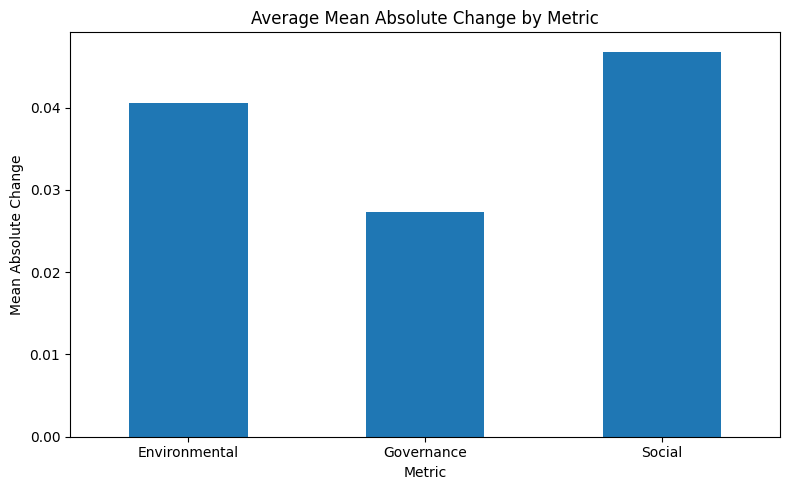

C:\Users\wongb\AppData\Local\Temp\ipykernel_26980\3706726951.py:144: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=metrics_sorted, showmeans=True)


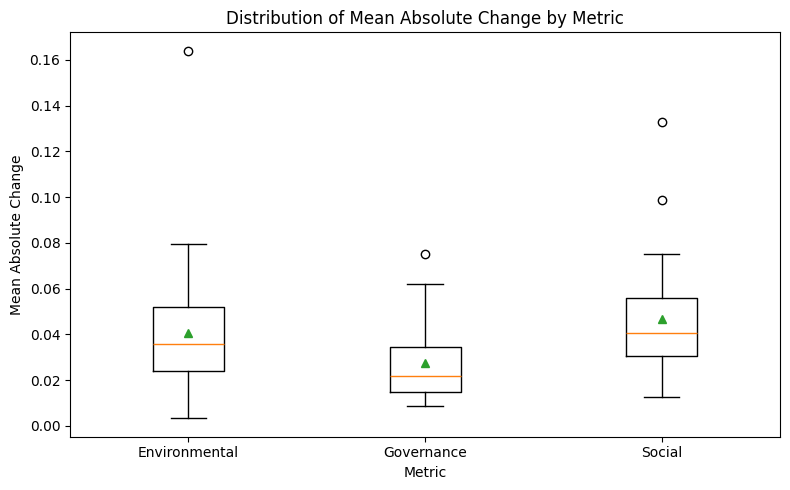

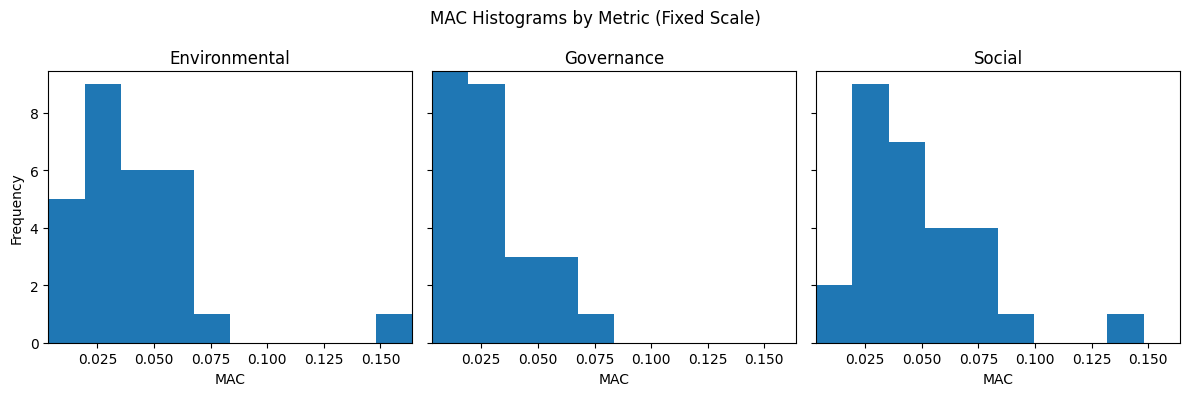

In [ ]:
from pathlib import Path
from itertools import combinations

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon



# --- Load MAC dataset ---
mac_csv_path = Path("outputs/master_ticker_metric_mean_absolute_change.csv")
if not mac_csv_path.exists():
    raise FileNotFoundError(f"MAC CSV not found: {mac_csv_path}")

mac_df = pd.read_csv(mac_csv_path)

required_cols = {"ticker", "metric", "mean_absolute_change", "n_changes"}
missing_cols = required_cols.difference(mac_df.columns)
if missing_cols:
    raise ValueError(f"MAC CSV missing required columns: {sorted(missing_cols)}")

# Keep only valid numeric MAC rows for stats/plots
plot_df = mac_df.copy()
plot_df["mean_absolute_change"] = pd.to_numeric(plot_df["mean_absolute_change"], errors="coerce")
plot_df = plot_df.dropna(subset=["mean_absolute_change"])

if plot_df.empty:
    raise RuntimeError("No valid mean_absolute_change values found in MAC CSV.")


# --- Summary statistics ---
print("=== Overall Summary (mean_absolute_change) ===")
print(plot_df["mean_absolute_change"].describe())

print("\n=== Summary by Metric ===")
summary_by_metric = (
    plot_df.groupby("metric")["mean_absolute_change"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_index()
)
print(summary_by_metric)

# Also save summary table for downstream use
summary_out_path = Path("outputs/master_ticker_metric_mean_absolute_change_summary.csv")
summary_by_metric.to_csv(summary_out_path, encoding="utf-8")
print(f"\nSaved summary table: {summary_out_path}")


# --- Pairwise statistical tests (paired) ---
# Build ticker x metric matrix so tests are paired by ticker
wide = plot_df.pivot_table(
    index="ticker",
    columns="metric",
    values="mean_absolute_change",
    aggfunc="first",
)

metrics_sorted = sorted(wide.columns.tolist())
test_rows = []

for metric_a, metric_b in combinations(metrics_sorted, 2):
    pair_df = wide[[metric_a, metric_b]].dropna()
    n_pairs = len(pair_df)

    if n_pairs < 2:
        test_rows.append(
            {
                "metric_a": metric_a,
                "metric_b": metric_b,
                "n_pairs": n_pairs,
                "mean_diff_a_minus_b": None,
                "ttest_stat": None,
                "ttest_pvalue": None,
                "wilcoxon_stat": None,
                "wilcoxon_pvalue": None,
                "note": "insufficient pairs",
            }
        )
        continue

    a_vals = pair_df[metric_a].astype(float)
    b_vals = pair_df[metric_b].astype(float)
    diffs = a_vals - b_vals

    mean_diff = float(diffs.mean())

    # Paired t-test
    t_stat, t_p = ttest_rel(a_vals, b_vals, nan_policy="omit")

    # Wilcoxon signed-rank (can fail if all diffs are zero)
    try:
        w_stat, w_p = wilcoxon(a_vals, b_vals)
    except ValueError:
        w_stat, w_p = None, None

    test_rows.append(
        {
            "metric_a": metric_a,
            "metric_b": metric_b,
            "n_pairs": n_pairs,
            "mean_diff_a_minus_b": mean_diff,
            "ttest_stat": float(t_stat) if pd.notna(t_stat) else None,
            "ttest_pvalue": float(t_p) if pd.notna(t_p) else None,
            "wilcoxon_stat": float(w_stat) if w_stat is not None else None,
            "wilcoxon_pvalue": float(w_p) if w_p is not None else None,
            "note": "",
        }
    )

tests_df = pd.DataFrame(test_rows)
print("\n=== Pairwise Paired Tests (MAC by metric) ===")
print(tests_df)

tests_out_path = Path("outputs/master_ticker_metric_pairwise_tests.csv")
tests_df.to_csv(tests_out_path, index=False, encoding="utf-8")
print(f"\nSaved pairwise tests: {tests_out_path}")


# --- Graph 1: Bar chart of mean MAC by metric ---
mean_by_metric = plot_df.groupby("metric", sort=True)["mean_absolute_change"].mean()

plt.figure(figsize=(8, 5))
mean_by_metric.plot(kind="bar")
plt.title("Average Mean Absolute Change by Metric")
plt.xlabel("Metric")
plt.ylabel("Mean Absolute Change")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# --- Graph 2: Boxplot of MAC distribution by metric ---
box_data = [
    plot_df.loc[plot_df["metric"] == metric, "mean_absolute_change"].values
    for metric in metrics_sorted
]

plt.figure(figsize=(8, 5))
plt.boxplot(box_data, labels=metrics_sorted, showmeans=True)
plt.title("Distribution of Mean Absolute Change by Metric")
plt.xlabel("Metric")
plt.ylabel("Mean Absolute Change")
plt.tight_layout()
plt.show()


# --- Graph 3: Histograms per metric with fixed comparable scales ---
global_min = float(plot_df["mean_absolute_change"].min())
global_max = float(plot_df["mean_absolute_change"].max())

# Avoid zero-width range if all values are equal
if global_min == global_max:
    global_max = global_min + 1e-9

fig, axes = plt.subplots(1, len(metrics_sorted), figsize=(4 * len(metrics_sorted), 4), sharey=True)
if len(metrics_sorted) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics_sorted):
    vals = plot_df.loc[plot_df["metric"] == metric, "mean_absolute_change"]
    ax.hist(vals, bins=10, range=(global_min, global_max))
    ax.set_title(metric)
    ax.set_xlabel("MAC")
    ax.set_xlim(global_min, global_max)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel("Frequency")
fig.suptitle("MAC Histograms by Metric (Fixed Scale)")
fig.tight_layout()
plt.show()


In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


mac_csv_path = Path("outputs/master_ticker_metric_mean_absolute_change.csv")
if not mac_csv_path.exists():
    raise FileNotFoundError(f"MAC CSV not found: {mac_csv_path}")

mac_df = pd.read_csv(mac_csv_path)

required_cols = {"ticker", "metric", "mean_absolute_change"}
missing_cols = required_cols.difference(mac_df.columns)
if missing_cols:
    raise ValueError(f"MAC CSV missing required columns: {sorted(missing_cols)}")

mac_df["mean_absolute_change"] = pd.to_numeric(mac_df["mean_absolute_change"], errors="coerce")
mac_df = mac_df.dropna(subset=["mean_absolute_change"])

# Ticker x metric matrix of volatility (MAC)
wide = mac_df.pivot_table(
    index="ticker",
    columns="metric",
    values="mean_absolute_change",
    aggfunc="first",
)

if wide.shape[1] < 2:
    raise RuntimeError("Need at least two metrics to compute correlations.")

pearson_corr = wide.corr(method="pearson", min_periods=2)
spearman_corr = wide.corr(method="spearman", min_periods=2)

print("=== Pearson Correlation (MAC across metrics) ===")
print(pearson_corr.round(4))

print("\n=== Spearman Correlation (MAC across metrics) ===")
print(spearman_corr.round(4))

pearson_out = Path("outputs/master_ticker_metric_mac_correlation_pearson.csv")
spearman_out = Path("outputs/master_ticker_metric_mac_correlation_spearman.csv")
pearson_corr.to_csv(pearson_out, encoding="utf-8")
spearman_corr.to_csv(spearman_out, encoding="utf-8")

print(f"\nSaved Pearson correlation matrix: {pearson_out}")
print(f"Saved Spearman correlation matrix: {spearman_out}")

# --- Heatmap-style visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, corr_df, title in [
    (axes[0], pearson_corr, "Pearson Correlation Heatmap (MAC)"),
    (axes[1], spearman_corr, "Spearman Correlation Heatmap (MAC)"),
]:
    im = ax.imshow(corr_df.values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=30, ha="right")
    ax.set_yticklabels(corr_df.index)

    for i in range(corr_df.shape[0]):
        for j in range(corr_df.shape[1]):
            val = corr_df.iat[i, j]
            text_color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=9)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label("Correlation Coefficient")

plt.show()

=== Pearson Correlation (MAC across metrics) ===
metric         Environmental  Governance  Social
metric                                          
Environmental         1.0000      0.4777  0.8399
Governance            0.4777      1.0000  0.7917
Social                0.8399      0.7917  1.0000

=== Spearman Correlation (MAC across metrics) ===
metric         Environmental  Governance  Social
metric                                          
Environmental         1.0000      0.4505  0.7783
Governance            0.4505      1.0000  0.8369
Social                0.7783      0.8369  1.0000

Saved Pearson correlation matrix: outputs\master_ticker_metric_mac_correlation_pearson.csv
Saved Spearman correlation matrix: outputs\master_ticker_metric_mac_correlation_spearman.csv
